In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import spatialtools as st

figure_dir = "figures/revision/supplement-extra"
st.utils.setup_plotting(figure_dir)

import decoupler as dc
import matplotlib.pyplot as plt
import scanpy as sc

from spatial_tcr.tcr import get_tcr_genes

In [50]:
data_dir = "data/xenium/processed"
path = f"{data_dir}/08.1-kidney_tcr_clonal_clusters.h5ad"
adata = sc.read_h5ad(path)
adata = adata[adata.obs["condition"] == "ANCA"].copy()
adata

AnnData object with n_obs × n_vars = 389390 × 431
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate', 'cell_type_l1.1', 'av_

In [51]:
cc_key = "avbv_cluster_filtered"
infiltrate_key = "tcell_infiltrate"

In [52]:
adata.obs[infiltrate_key].value_counts()

tcell_infiltrate
no infiltrate    360934
infiltrate        28456
Name: count, dtype: int64

In [53]:
ad_t = adata[adata.obs["cell_type_l1"] == "T"].copy()
ad_t.obs["in_clonal_cluster"] = (
    ad_t.obs[cc_key].isin(ad_t.obs[cc_key].dropna().unique()).astype(str)
)

# remove trv genes
tv_genes = get_tcr_genes(ad_t)[-1]
ad_t = ad_t[:, [g for g in ad_t.var_names if g not in tv_genes]].copy()

ad_t.X = ad_t.layers["counts"].copy()
sc.pp.normalize_total(ad_t)
sc.pp.log1p(ad_t)

Found 35 TRAV genes, 31 TRBV genes, 3 TRDV genes, 14 TRGV genes


In [54]:
ad_t_infilt = ad_t[ad_t.obs[infiltrate_key] == "infiltrate"].copy()
ad_t_non_infilt = ad_t[ad_t.obs[infiltrate_key] == "no infiltrate"].copy()

In [55]:
figsize = (4.5, 3.5)

... storing 'in_clonal_cluster' as categorical


1 [-0.8612817   0.73972239]
2 [ 0.34381874 -0.76316082]


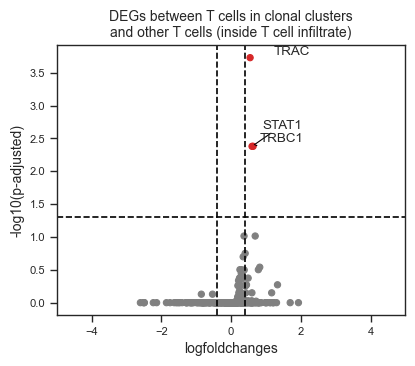

In [56]:
sc.tl.rank_genes_groups(
    ad_t_infilt, groupby="in_clonal_cluster", method="wilcoxon", use_raw=False
)
# sc.pl.rank_genes_groups_dotplot(
#     ad_t_infilt, groupby="in_clonal_cluster", standard_scale="var", n_genes=10
# )
de_df = sc.get.rank_genes_groups_df(ad_t_infilt, group="True").set_index("names")
fig, ax = plt.subplots(1, 1, figsize=figsize)
dc.pl.volcano(de_df, x="logfoldchanges", y="pvals_adj", ax=ax, top=15, thr_stat=0.4)
ax.set_xlim(-5, 5)
ax.tick_params(axis="both", labelsize=8)
ax.xaxis.label.set_size(10)
ax.yaxis.label.set_size(10)
# ax.set_xlim(-5, 5)
ax.set_title(
    "DEGs between T cells in clonal clusters\nand other T cells (inside T cell infiltrate)",
    fontsize=10,
)
ax.set_ylabel("-log10(p-adjusted)", fontsize=10)
# fig.subplots_adjust(left=0.2)
# fig.tight_layout()
plt.savefig(
    f"{figure_dir}/DEGs_clonal_cluster_inside_tcell_infiltrate.pdf",
    dpi=300,
    bbox_inches="tight",
)

In [57]:
de_df = sc.get.rank_genes_groups_df(ad_t_infilt, group="True").set_index("names")
log2fc_cutoff = 0.0
pvalue_cutoff = 0.05
mask_1 = de_df["pvals_adj"] < pvalue_cutoff
mask_2 = de_df["logfoldchanges"] > log2fc_cutoff
# mask_3 = de_df["logfoldchanges"] < -log2fc_cutoff
mask = mask_1 & mask_2
de_df = de_df.loc[mask]
de_df

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
TRAC,5.012407,0.545196,5.375337e-07,0.000187
STAT1,4.179540,0.600860,2.920994e-05,0.004176
TRBC1,4.131777,0.630946,3.599688e-05,0.004176


... storing 'in_clonal_cluster' as categorical


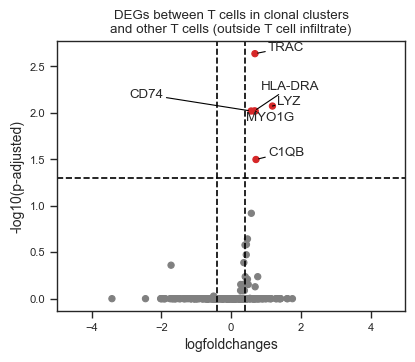

In [58]:
# differentially expressed genes between expanded and other T cells
sc.tl.rank_genes_groups(
    ad_t_non_infilt, groupby="in_clonal_cluster", method="wilcoxon", use_raw=False
)
de_df = sc.get.rank_genes_groups_df(ad_t_non_infilt, group="True").set_index("names")
fig, ax = plt.subplots(1, 1, figsize=figsize)
dc.pl.volcano(de_df, x="logfoldchanges", y="pvals_adj", ax=ax, top=15, thr_stat=0.4)
ax.set_xlim(-5, 5)
ax.tick_params(axis="both", labelsize=8)
ax.xaxis.label.set_size(10)
ax.yaxis.label.set_size(10)
ax.set_title(
    "DEGs between T cells in clonal clusters\nand other T cells (outside T cell infiltrate)"
)
ax.set_ylabel("-log10(p-adjusted)", fontsize=10)
plt.savefig(
    f"{figure_dir}/DEGs_clonal_cluster_outside_tcell_infiltrate.pdf",
    dpi=300,
    bbox_inches="tight",
)

In [59]:
de_df = sc.get.rank_genes_groups_df(ad_t_non_infilt, group="True").set_index("names")
log2fc_cutoff = 0.0
pvalue_cutoff = 0.05
mask_1 = de_df["pvals_adj"] < pvalue_cutoff
mask_2 = de_df["logfoldchanges"] > log2fc_cutoff
# mask_3 = de_df["logfoldchanges"] < -log2fc_cutoff
mask = mask_1 & mask_2
de_df = de_df.loc[mask]
de_df

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
TRAC,4.505478,0.684111,0.000007,0.002305
LYZ,4.062763,1.185866,0.000048,0.008438
HLA-DRA,3.936663,0.662857,0.000083,0.009547
CD74,3.859108,0.573676,0.000114,0.009547
MYO1G,3.813209,0.691598,0.000137,0.009547
C1QB,3.456414,0.713829,0.000547,0.031750


## Also compare inside and outside T cell infiltrate

In [60]:
ad_cluster = ad_t[ad_t.obs["in_clonal_cluster"] == "True"].copy()
ad_other_t = ad_t[ad_t.obs["in_clonal_cluster"] == "False"].copy()

In [61]:
ad_t.obs[infiltrate_key].value_counts()

tcell_infiltrate
no infiltrate    13246
infiltrate        6375
Name: count, dtype: int64

... storing 'in_clonal_cluster' as categorical


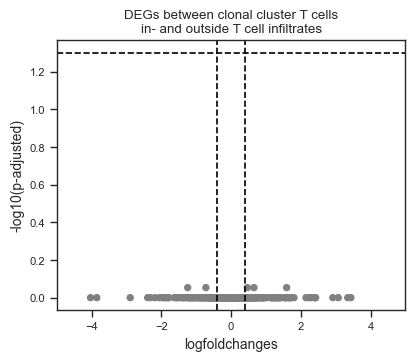

In [62]:
sc.tl.rank_genes_groups(
    ad_cluster, groupby=infiltrate_key, method="wilcoxon", use_raw=False
)

de_df = sc.get.rank_genes_groups_df(ad_cluster, group="infiltrate").set_index("names")
fig, ax = plt.subplots(1, 1, figsize=figsize)
dc.pl.volcano(de_df, x="logfoldchanges", y="pvals_adj", ax=ax, top=15, thr_stat=0.4)
ax.set_xlim(-5, 5)
ax.tick_params(axis="both", labelsize=8)
ax.xaxis.label.set_size(10)
ax.yaxis.label.set_size(10)
# ax.set_xlim(-5, 5)
ax.set_title("DEGs between clonal cluster T cells\nin- and outside T cell infiltrates")
ax.set_ylabel("-log10(p-adjusted)", fontsize=10)
plt.savefig(
    f"{figure_dir}/DEGs_clonal_cluster_inside_outside_tcell_infiltrate.pdf",
    dpi=300,
    bbox_inches="tight",
)

... storing 'in_clonal_cluster' as categorical


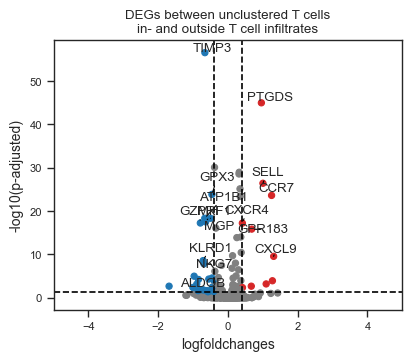

In [63]:
sc.tl.rank_genes_groups(
    ad_other_t, groupby=infiltrate_key, method="wilcoxon", use_raw=False
)

de_df = sc.get.rank_genes_groups_df(ad_other_t, group="infiltrate").set_index("names")
fig, ax = plt.subplots(1, 1, figsize=figsize)
dc.pl.volcano(de_df, x="logfoldchanges", y="pvals_adj", ax=ax, top=15, thr_stat=0.4)
ax.set_xlim(-5, 5)
ax.tick_params(axis="both", labelsize=8)
ax.xaxis.label.set_size(10)
ax.yaxis.label.set_size(10)
# ax.set_xlim(-5, 5)
ax.set_title("DEGs between unclustered T cells\nin- and outside T cell infiltrates")
ax.set_ylabel("-log10(p-adjusted)", fontsize=10)
plt.savefig(
    f"{figure_dir}/DEGs_tcell_inside_outside_tcell_infiltrate.pdf",
    dpi=300,
    bbox_inches="tight",
)